In [5]:
import os
import re
import nltk
import pandas as pd
import numpy as np
import requests
import zipfile
import io
import joblib
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

In [6]:
file_path = r'anomaly_detection_collection/KDD+.txt'

# Define the column names corresponding to the NSL-KDD dataset
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 
    'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack', 'level'
]

In [11]:
print(f"Number of Columns: {len(columns)}")

Number of Columns: 43


In [7]:
df = pd.read_csv(file_path, names=columns)

In [8]:
df.shape

(148517, 43)

In [12]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [13]:
df['attack_flag'] = df['attack'].apply(lambda a: 0 if a == 'normal' else 1)

In [14]:
df['attack']

0          normal
1          normal
2         neptune
3          normal
4          normal
           ...   
148512     normal
148513     normal
148514       back
148515     normal
148516      mscan
Name: attack, Length: 148517, dtype: str

In [15]:
# Multi-class classification target categories
dos_attacks = ['apache2', 'back', 'land', 'neptune', 'mailbomb', 'pod', 'processtable', 'smurf', 'teardrop', 'udpstorm', 'worm']

probe_attacks = ['ipsweep', 'mscan', 'nmap', 'portsweep', 'saint', 'satan']

privilege_attacks = ['buffer_overflow', 'loadmdoule', 'perl', 'ps','rootkit', 'sqlattack', 'xterm']

access_attacks = ['ftp_write', 'guess_passwd', 'http_tunnel', 'imap', 'multihop', 'named', 'phf', 'sendmail', 'snmpgetattack', 'snmpguess', 'spy', 'warezclient', 'warezmaster', 'xclock', 'xsnoop']

def map_attack(attack):
    if attack in dos_attacks:
        return 1
    elif attack in probe_attacks:
        return 2
    elif attack in privilege_attacks:
        return 3
    elif attack in access_attacks:
        return 4
    else:
        return 0

# Assign multi-class category to each row
df['attack_map'] = df['attack'].apply(map_attack)

In [18]:
# protocol_type and service columns
df[['protocol_type', 'service']]

,protocol_type,service
0,tcp,ftp_data
1,udp,other
2,tcp,private
3,tcp,http
4,tcp,http
...,...,...
148512,tcp,smtp
148513,tcp,http
148514,tcp,http
148515,udp,domain_u


In [19]:
# Encoding categorical variables
features_to_encode = ['protocol_type', 'service']
# get_dummies does one hot encoding
encoded = pd.get_dummies(df[features_to_encode])

In [20]:
# Print encoded
encoded

,protocol_type_icmp,protocol_type_tcp,protocol_type_udp,service_IRC,service_X11,service_Z39_50,service_aol,service_auth,service_bgp,service_courier,...,service_telnet,service_tftp_u,service_tim_i,service_time,service_urh_i,service_urp_i,service_uucp,service_uucp_path,service_vmnet,service_whois
0,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148512,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
148513,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
148514,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
148515,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [21]:
# Numeric features that capture various statistical properties of the traffic
numeric_features = [
    'duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'urgent', 'hot', 
    'num_failed_logins', 'num_compromised', 'root_shell', 'su_attempted', 
    'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 
    'num_outbound_cmds', 'count', 'srv_count', 'serror_rate', 
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 
    'dst_host_srv_rerror_rate'
]


In [23]:
print(f"Length of Numeric Features: {len(numeric_features)}")

Length of Numeric Features: 34


In [24]:
df[numeric_features]

,duration,src_bytes,dst_bytes,wrong_fragment,urgent,hot,num_failed_logins,num_compromised,root_shell,su_attempted,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,491,0,0,0,0,0,0,0,0,...,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00
1,0,146,0,0,0,0,0,0,0,0,...,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00
2,0,0,0,0,0,0,0,0,0,0,...,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00
3,0,232,8153,0,0,0,0,0,0,0,...,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01
4,0,199,420,0,0,0,0,0,0,0,...,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148512,0,794,333,0,0,0,0,0,0,0,...,100,141,0.72,0.06,0.01,0.01,0.01,0.00,0.00,0.00
148513,0,317,938,0,0,0,0,0,0,0,...,197,255,1.00,0.00,0.01,0.01,0.01,0.00,0.00,0.00
148514,0,54540,8314,0,0,2,0,1,0,0,...,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.07,0.07
148515,0,42,42,0,0,0,0,0,0,0,...,255,252,0.99,0.01,0.00,0.00,0.00,0.00,0.00,0.00


In [25]:
# Combine encoded categorical variables and numeric features
train_set = encoded.join(df[numeric_features])

# Multi-class target variable
multi_y = df['attack_map']

In [33]:
print(f"Tranining Set: ")
train_set

Tranining Set: 


,protocol_type_icmp,protocol_type_tcp,protocol_type_udp,service_IRC,service_X11,service_Z39_50,service_aol,service_auth,service_bgp,service_courier,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,False,True,False,False,False,False,False,False,False,False,...,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00
1,False,False,True,False,False,False,False,False,False,False,...,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00
2,False,True,False,False,False,False,False,False,False,False,...,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00
3,False,True,False,False,False,False,False,False,False,False,...,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01
4,False,True,False,False,False,False,False,False,False,False,...,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148512,False,True,False,False,False,False,False,False,False,False,...,100,141,0.72,0.06,0.01,0.01,0.01,0.00,0.00,0.00
148513,False,True,False,False,False,False,False,False,False,False,...,197,255,1.00,0.00,0.01,0.01,0.01,0.00,0.00,0.00
148514,False,True,False,False,False,False,False,False,False,False,...,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.07,0.07
148515,False,False,True,False,False,False,False,False,False,False,...,255,252,0.99,0.01,0.00,0.00,0.00,0.00,0.00,0.00


In [35]:
print("Target variable")
multi_y

Target variable


0         0
1         0
2         1
3         0
4         0
         ..
148512    0
148513    0
148514    1
148515    0
148516    2
Name: attack_map, Length: 148517, dtype: int64

In [38]:
# Split data into training and test sets for multi-class classification
train_X, test_X, train_y, test_y = train_test_split(train_set, multi_y, test_size=0.2, random_state=1337)

# train_set -> train_X + test_X 
# train_X -> multi_train and multi_val

In [39]:
# Further split the training set into separate training and validation sets
multi_train_X, multi_val_X, multi_train_y, multi_val_y = train_test_split(train_X, train_y, test_size=0.3, random_state=1337)

In [40]:
train_X, train_y

(        protocol_type_icmp  protocol_type_tcp  protocol_type_udp  service_IRC  \
 46323                False               True              False        False   
 126905               False              False               True        False   
 5989                 False               True              False        False   
 79922                False               True              False        False   
 121463               False               True              False        False   
 ...                    ...                ...                ...          ...   
 91220                False               True              False        False   
 71538                False               True              False        False   
 117415               False               True              False        False   
 9448                 False               True              False        False   
 3223                 False               True              False        False   
 
         servi

In [73]:
from sklearn.ensemble import RandomForestClassifier

# Train RandomForest model for multi-class classification
rf_model_multi = RandomForestClassifier(
    random_state=1337, 
    n_jobs=-1, 
    class_weight='balanced',
    max_depth=12
)

rf_model_multi.fit(multi_train_X, multi_train_y)

# USED multi_train to train random forest model

,n_estimators,100
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Validation Set Evaluation:
Accuracy: 0.9825
Precision: 0.9867
Recall: 0.9825
F1-Score: 0.9837


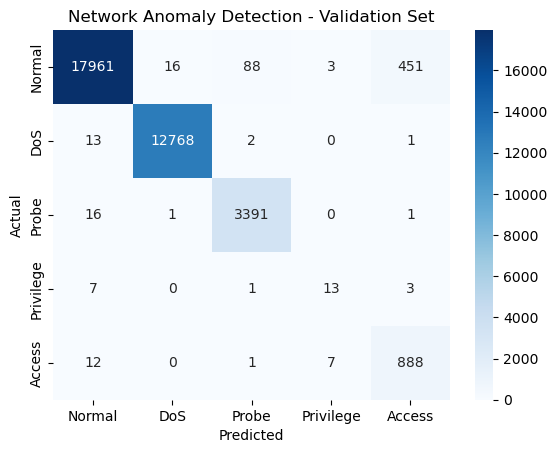

Classification Report for Validation Set:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98     18519
         DoS       1.00      1.00      1.00     12784
       Probe       0.97      0.99      0.98      3409
   Privilege       0.57      0.54      0.55        24
      Access       0.66      0.98      0.79       908

    accuracy                           0.98     35644
   macro avg       0.84      0.90      0.86     35644
weighted avg       0.99      0.98      0.98     35644



In [74]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predict and evaluate the model on the validation set
multi_predictions = rf_model_multi.predict(multi_val_X)
accuracy = accuracy_score(multi_val_y, multi_predictions)
precision = precision_score(multi_val_y, multi_predictions, average='weighted')
recall = recall_score(multi_val_y, multi_predictions, average='weighted')
f1 = f1_score(multi_val_y, multi_predictions, average='weighted')
print(f"Validation Set Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Confusion Matrix for Validation Set
conf_matrix = confusion_matrix(multi_val_y, multi_predictions)
class_labels = ['Normal', 'DoS', 'Probe', 'Privilege', 'Access']
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Network Anomaly Detection - Validation Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report for Validation Set
print("Classification Report for Validation Set:")
print(classification_report(multi_val_y, multi_predictions, target_names=class_labels))

In [ ]:
# Wirth default Random Forest Model Privesc f1 score is 0.51
# There is class imbalance?

In [59]:
import joblib

# Save the trained model to a file
model_filename = 'network_anomaly_detection_model.joblib'
joblib.dump(rf_model_multi, model_filename)

print(f"Model saved to {model_filename}")

Model saved to network_anomaly_detection_model.joblib
